In [16]:
import pandas as pd
import numpy as np
import os
import re
import subprocess
import nltk
import wget
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.snowball import SnowballStemmer
from string import punctuation

import pymorphy2
from pymorphy2 import MorphAnalyzer
from gensim.models import Word2Vec, FastText
import gensim.matutils
from gensim.models import KeyedVectors

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

import json

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, accuracy_score
from ufal.udpipe import Model, Pipeline
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

positive_file = 'positive.csv'
negative_file = 'negative.csv'

pos = pd.read_csv(positive_file, sep=';', names=['id', 'date', 'name', 'text', 'type', 'rep', 'rtw', 'faw', 'stcount', 'foll', 'frien', 'listcount'])
neg = pd.read_csv(negative_file, sep=';', names=['id', 'date', 'name', 'text', 'type', 'rep', 'rtw', 'faw', 'stcount', 'foll', 'frien', 'listcount'])

neg['type'] = neg['type'].replace(-1, 0)
df = pd.concat([pos, neg])

df = df.drop(['id', 'date', 'name', 'rep', 'rtw', 'faw', 'stcount', 'foll', 'frien', 'listcount'], axis=1)

stop_words = set(stopwords.words('russian'))

morph = MorphAnalyzer()

def normalize_text(text):
    text = text.lower()
    text = re.sub('[^а-яё ]', '', text)
    text = re.sub('\\s+', ' ', text).strip()
    words = [word for word in text.split() if word not in stop_words]
    words = [morph.parse(word)[0].normal_form for word in words]

    return ' '.join(words)

df['normalized_text'] = df['text'].apply(normalize_text)

df['tokens'] = df['normalized_text'].apply(word_tokenize)

df.to_csv('tokenormalized.csv')

df

[nltk_data] Downloading package punkt to /home/artyom/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/artyom/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/artyom/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,text,type,normalized_text,tokens
0,"@first_timee хоть я и школота, но поверь, у на...",1,школотый поверь самый общество профилировать п...,"[школотый, поверь, самый, общество, профилиров..."
1,"Да, все-таки он немного похож на него. Но мой ...",1,всетаки немного похожий мальчик равно,"[всетаки, немного, похожий, мальчик, равно]"
2,RT @KatiaCheh: Ну ты идиотка) я испугалась за ...,1,идиотка испугаться,"[идиотка, испугаться]"
3,"RT @digger2912: ""Кто то в углу сидит и погибае...",1,угол сидеть погибать голод ещё порция взять хо...,"[угол, сидеть, погибать, голод, ещё, порция, в..."
4,@irina_dyshkant Вот что значит страшилка :D\nН...,1,значит страшилка блинпосмотреть частиу создать...,"[значит, страшилка, блинпосмотреть, частиу, со..."
...,...,...,...,...
111918,Но не каждый хочет что то исправлять:( http://...,0,каждый хотеть исправлять,"[каждый, хотеть, исправлять]"
111919,скучаю так :-( только @taaannyaaa вправляет мо...,0,скучать вправлять мозг равно скучать,"[скучать, вправлять, мозг, равно, скучать]"
111920,"Вот и в школу, в говно это идти уже надо(",0,школа говно это идти,"[школа, говно, это, идти]"
111921,"RT @_Them__: @LisaBeroud Тауриэль, не грусти :...",0,тауриэль грусть обнять,"[тауриэль, грусть, обнять]"


In [ ]:
# Загружаем данные из CSV-файла 'tokenormalized.csv' в DataFrame pandas
df = pd.read_csv('tokenormalized.csv')

# Разбиваем данные на обучающую и тестовую выборки
# X_train, X_test — части признаков (в данном случае столбец 'tokens')
# y_train, y_test — части целевой переменной (столбец 'type')
# test_size=0.2 означает, что 20% данных уйдут в тестовую выборку, 80% — в обучающую
# random_state=42 фиксирует случайное разбиение для воспроизводимости результатов
X_train, X_test, y_train, y_test = train_test_split(
    df['tokens'], df['type'], test_size=0.2, random_state=42
)

In [ ]:
# Обучаем модель Word2Vec на токенах из столбца 'tokens' DataFrame df
# Параметры:
# - sentences=df['tokens']: список предложений, где каждое предложение — список токенов
# - vector_size=100: размерность векторного представления каждого слова
# - window=5: максимальное расстояние между текущим и предсказанным словом в предложении
# - min_count=1: минимальное количество появлений слова для его включения в словарь модели
# - workers=4: количество потоков для параллельного обучения
word2vec_model = Word2Vec(
    sentences=df['tokens'], vector_size=100, window=5, min_count=1, workers=4
)
# Функция для получения векторного представления предложения (списка токенов)
def get_word2vec_features(tokens, model, vector_size=100):
    # Получаем векторы всех слов, которые есть в словаре модели
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    # Если векторы есть, возвращаем среднее по всем векторам слов (агрегация)
    # Если векторов нет (например, пустой список), возвращаем нулевой вектор нужной размерности
    return np.mean(vectors, axis=0) if vectors else np.zeros(vector_size)

# Преобразуем обучающие данные: для каждого списка токенов из X_train получаем векторное представление
X_train_w2v = np.array([get_word2vec_features(tokens, word2vec_model) for tokens in X_train])
# Аналогично преобразуем тестовые данные
x_test_w2v = np.array([get_word2vec_features(tokens, word2vec_model) for tokens in X_test])

In [ ]:
# Обучаем модель FastText на токенах из столбца 'tokens' DataFrame df
# Параметры:
# - sentences=df['tokens']: список предложений, где каждое предложение — список токенов
# - vector_size=100: размерность векторного представления каждого слова
# - window=5: максимальное расстояние между текущим и предсказанным словом в предложении
# - min_count=1: минимальное количество появлений слова для его включения в словарь модели
# - workers=4: количество потоков для параллельного обучения
fasttext_model = FastText(
    sentences=df['tokens'], vector_size=100, window=5, min_count=1, workers=4
)
# Функция для получения векторного представления предложения (списка токенов) с помощью FastText

def get_fasttext_features(tokens, model, vector_size=100):
    # Получаем векторы всех слов, которые есть в словаре модели FastText
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    # Если векторы есть, возвращаем среднее по всем векторам слов (агрегация)
    # Если векторов нет (например, пустой список), возвращаем нулевой вектор нужной размерности
    return np.mean(vectors, axis=0) if vectors else np.zeros(vector_size)

# Преобразуем обучающие данные: для каждого списка токенов из X_train получаем векторное представление FastText
X_train_ft = np.array([get_fasttext_features(tokens, fasttext_model) for tokens in X_train])
# Аналогично преобразуем тестовые данные
X_test_ft = np.array([get_fasttext_features(tokens, fasttext_model) for tokens in X_test])

In [ ]:
# Создаем класс TextDataset для подготовки данных к использованию с PyTorch DataLoader и nn.Embedding# Ячейка: Создание Dataset для nn.Embedding
class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=100):
        """
        Инициализация датасета.
        :param texts: pandas.Series или список списков токенов (тексты)
        :param labels: pandas.Series или список меток (целевые значения)
        :param vocab: словарь {слово: индекс}, где индекс — целое число для эмбеддинга
        :param max_len: максимальная длина последовательности (для обрезки/дополнения)
        """
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        # Возвращает количество примеров в датасете
        return len(self.labels)

    def __getitem__(self, idx):
        # Получаем текст по индексу idx
        text = self.texts.iloc[idx]
        # Преобразуем слова в индексы по словарю vocab
        # Если слово отсутствует в словаре, используем индекс 1 (обычно для OOV — out-of-vocabulary)
        indices = [self.vocab.get(word, 1) for word in text]  # 1 для OOV
        # Обрезаем или дополняем последовательность до длины max_len
        # Если длина меньше max_len, дополняем нулями (индекс 0 обычно для padding)
        indices = indices[:self.max_len] + [0]*(self.max_len - len(indices))
        # Возвращаем кортеж из тензора индексов слов (типа long) и тензора метки (float)
        return torch.tensor(indices, dtype=torch.long), torch.tensor(self.labels.iloc[idx], dtype=torch.float)

In [ ]:
# Определяем функцию для построения словаря (вокабуляра) по спискам токенов
def build_vocab(texts):
    """
    Создает словарь, сопоставляющий каждому уникальному слову уникальный индекс.
    В словарь добавляются специальные токены:
    - '<pad>': индекс 0 — для заполнения последовательностей до одинаковой длины
    - '<unk>': индекс 1 — для слов, отсутствующих в словаре (out-of-vocabulary)
    """
    vocab = {'<pad>': 0, '<unk>': 1} # Инициализация словаря с специальными токенами
    idx = 2 # Начинаем нумерацию с 2, так как 0 и 1 заняты
    for text in texts:
        for word in text:
            # Если слово еще не в словаре, добавляем его с новым индексом
            if word not in vocab:
                vocab[word] = idx
                idx += 1
    return vocab
# Создаем словарь по спискам токенов из столбца 'tokens' DataFrame df
vocab = build_vocab(df['tokens'])

In [ ]:
# Определяем класс нейронной сети для классификации
class SentimentClassifier(nn.Module):
    """
    Инициализация модели.
    :param vocab_size: размер словаря (количество уникальных токенов)
    :param embedding_dim: размерность эмбеддингов для слов
    :param hidden_dims: список размеров скрытых слоев полносвязной сети
    """
    def __init__(self, vocab_size, embedding_dim, hidden_dims):
        super().__init__()
        # Слой эмбеддинга: преобразует индексы слов в векторы фиксированной размерности
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        # Создаем последовательность полносвязных слоев с активациями ReLU
        layers = []
        input_dim = embedding_dim
        for dim in hidden_dims:
            layers.append(nn.Linear(input_dim, dim)) # линейный слой
            layers.append(nn.ReLU()) # функция активации ReLU
            input_dim = dim

        # Финальный линейный слой, который выводит одно число (например, логит для бинарной классификации)
        layers.append(nn.Linear(input_dim, 1))
         # Собираем все слои в один последовательный модуль
        self.classifier = nn.Sequential(*layers)

    """
    def forward(self, x):
        embedded = self.embedding(x).mean(dim=1)
        return self.classifier(embedded).squeeze()
    """

    def forward(self, x):
        # Преобразуем входные индексы слов в эмбеддинги размерности (batch_size, max_len, embedding_dim)
        embedded = self.embedding(x)
        # Усредняем эмбеддинги по длине последовательности (dim=1), чтобы получить один вектор на каждый пример
        embedded = embedded.mean(dim=1)
        # Пропускаем усредненный вектор через классификатор (последовательность полносвязных слоев)
        output = self.classifier(embedded)
        # Убираем лишнюю размерность, чтобы получить тензор формы (batch_size)
        return output.squeeze()


In [ ]:
# Функция для обучения модели нейронной сети и оценки её точности на тестовой выборке
def train_model(model, train_loader, test_loader, lr=0.001, epochs=5):
    # Оптимизатор Adam с заданной скоростью обучения
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # Функция потерь для бинарной классификации с логитами (BCEWithLogitsLoss)
    criterion = nn.BCEWithLogitsLoss()
    
    for epoch in range(epochs):
        model.train() # Переводим модель в режим обучения
        for inputs, labels in train_loader:
            optimizer.zero_grad() # Обнуляем градиенты
            outputs = model(inputs) # Прямой проход модели
            
            # Изменяем размерность labels для соответствия outputs
            labels = labels.view(-1, 1).float()
            
            loss = criterion(outputs, labels) # Вычисляем ошибку
            loss.backward() # Обратное распространение ошибки
            optimizer.step() # Обновление весов модели
    
    # Evaluation
    # Оценка модели на тестовой выборке
    model.eval() # Переводим модель в режим оценки
    all_preds = []
    all_labels = []
    with torch.no_grad(): # Отключаем вычисление градиентов для ускорения
        for inputs, labels in test_loader:
            outputs = torch.sigmoid(model(inputs)) # Применяем сигмоиду к выходам (логитам)
            preds = (outputs > 0.5).float() # Получаем бинарные предсказания (0 или 1)
            all_preds.extend(preds.cpu().numpy().flatten()) # Сохраняем предсказания
            all_labels.extend(labels.cpu().numpy()) # Сохраняем истинные метки
    # Возвращаем точность классификации
    return accuracy_score(all_labels, all_preds)

# Класс TextDataset для подготовки данных с учетом возможного строкового формата токенов
class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=100):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        # Возвращает количество примеров в датасете
        return len(self.labels)

    def __getitem__(self, idx):
        # Если текст представлен в виде строки, преобразуем его в список с помощью eval
        text = eval(self.texts.iloc[idx]) if isinstance(self.texts.iloc[idx], str) else self.texts.iloc[idx]
        # Преобразуем слова в индексы по словарю, 1 — индекс для неизвестных слов (OOV)
        indices = [self.vocab.get(word, 1) for word in text]  # 1 для OOV
        # Обрезаем или дополняем последовательность до длины max_len нулями (padding)
        indices = indices[:self.max_len] + [0]*(self.max_len - len(indices))
        # Возвращаем пару: тензор индексов слов и тензор метки (float32)
        return torch.tensor(indices, dtype=torch.long), torch.tensor(self.labels.iloc[idx], dtype=torch.float32)

# Цикл по конфигурациям нейросетей и скоростям обучения для обучения моделей на эмбеддингах Word2Vec и FastText# Ячейка: Обновленный код для Word2Vec и FastText
for config in configs:
    for lr in config['lrs']:
        # --- Word2Vec ---
        # Определяем простую модель с одним скрытым слоем и выходом на 1 нейрон
        model = nn.Sequential(
            nn.Linear(100, config['hidden_dims'][0]), # Вход 100 (размерность эмбеддинга), выход — размер скрытого слоя
            nn.ReLU(), # Активация ReLU
            nn.Linear(config['hidden_dims'][0], 1) # Выходной слой для бинарной классификации
        )
        
        # Преобразуем обучающие данные Word2Vec в тензоры PyTorch
        X_train_w2v_tensor = torch.FloatTensor(X_train_w2v)
        y_train_tensor = torch.FloatTensor(y_train.values).view(-1, 1)
        train_dataset = torch.utils.data.TensorDataset(X_train_w2v_tensor, y_train_tensor)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
        
        # Аналогично для тестовых данных
        X_test_w2v_tensor = torch.FloatTensor(x_test_w2v)
        y_test_tensor = torch.FloatTensor(y_test.values).view(-1, 1)
        test_dataset = torch.utils.data.TensorDataset(X_test_w2v_tensor, y_test_tensor)
        test_loader = DataLoader(test_dataset, batch_size=64)
        
        # Обучаем модель и получаем точность
        acc = train_model(model, train_loader, test_loader, lr=lr)
        # Сохраняем результаты эксперимента
        results.append({
            'type': 'Word2Vec',
            'layers': config['layers'],
            'neurons': '-'.join(map(str, config['hidden_dims'])),
            'lr': lr,
            'accuracy': acc
        })

        # --- FastText ---
        # Создаем такую же модель для эмбеддингов FastText
        model = nn.Sequential(
            nn.Linear(100, config['hidden_dims'][0]),
            nn.ReLU(),
            nn.Linear(config['hidden_dims'][0], 1)
        )
        
        # Преобразуем обучающие данные FastText в тензоры
        X_train_ft_tensor = torch.FloatTensor(X_train_ft)
        train_dataset = torch.utils.data.TensorDataset(X_train_ft_tensor, y_train_tensor)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
        
        # Аналогично для тестовых данных
        X_test_ft_tensor = torch.FloatTensor(X_test_ft)
        test_dataset = torch.utils.data.TensorDataset(X_test_ft_tensor, y_test_tensor)
        test_loader = DataLoader(test_dataset, batch_size=64)
        
        # Обучаем модель и получаем точность
        acc = train_model(model, train_loader, test_loader, lr=lr)
        # Сохраняем результаты эксперимента
        results.append({
            'type': 'FastText',
            'layers': config['layers'],
            'neurons': '-'.join(map(str, config['hidden_dims'])),
            'lr': lr,
            'accuracy': acc
        })

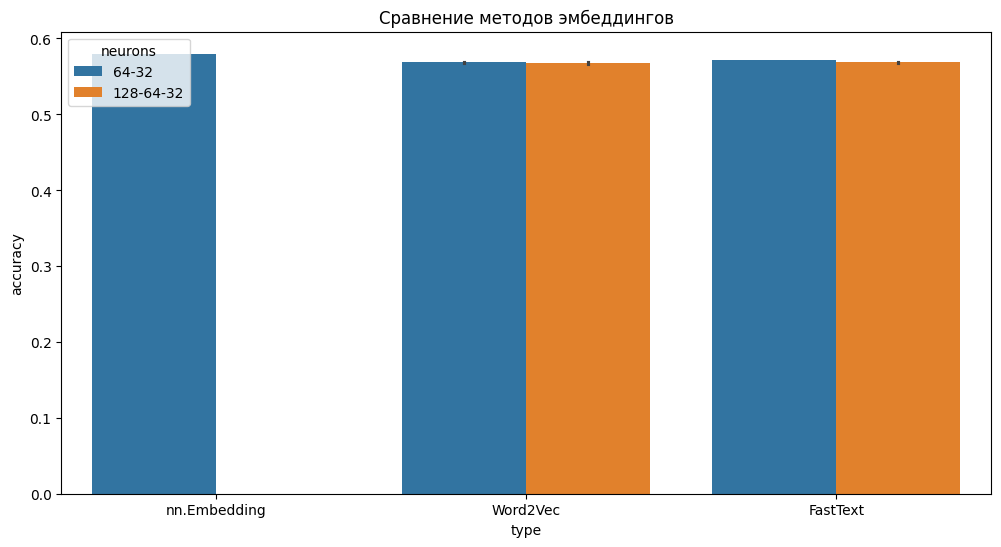

                                      accuracy
type         layers neurons   lr              
FastText     2      64-32     0.0010  0.571473
                              0.0100  0.571054
             3      128-64-32 0.0001  0.567108
                              0.0010  0.569467
Word2Vec     2      64-32     0.0010  0.568960
                              0.0100  0.567505
             3      128-64-32 0.0001  0.566800
                              0.0010  0.569379
nn.Embedding 2      64-32     0.0100  0.579783


In [17]:
# Ячейка: Визуализация результатов
results_df = pd.DataFrame(results)
plt.figure(figsize=(12, 6))
sns.barplot(x='type', y='accuracy', hue='neurons', data=results_df)
plt.title('Сравнение методов эмбеддингов')
plt.show()

print(results_df.groupby(['type', 'layers', 'neurons', 'lr']).mean())

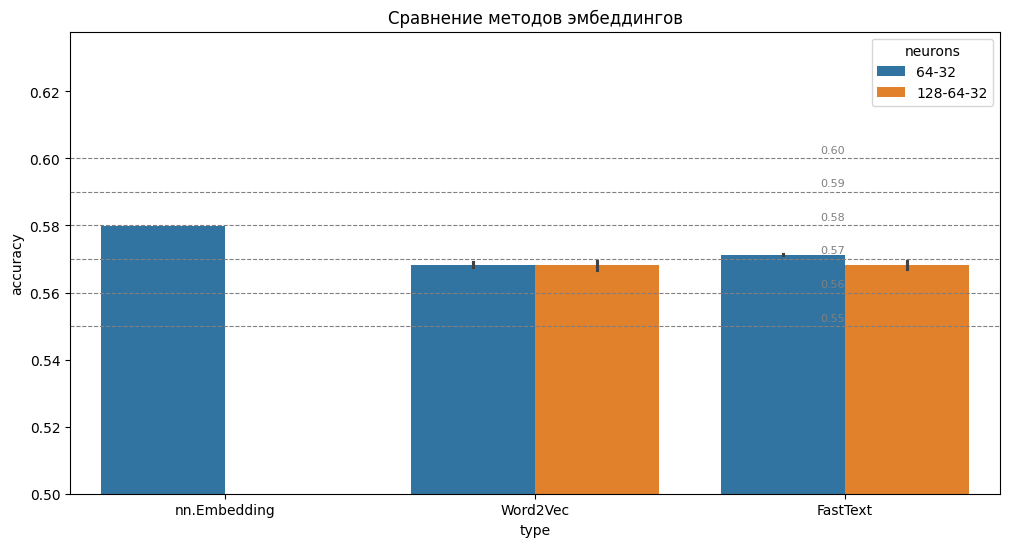

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Предполагаю, что results уже содержит ваши данные
results_df = pd.DataFrame(results)

# Создаем фигуру
plt.figure(figsize=(12, 6))

# Строим барплот
ax = sns.barplot(x='type', y='accuracy', hue='neurons', data=results_df)

# Задаем список значений accuracy, которые нужно отобразить
accuracy_levels = [0.55, 0.56, 0.57, 0.58, 0.59, 0.60]

# Добавляем горизонтальные линии для каждого уровня accuracy
for level in accuracy_levels:
    ax.axhline(y=level, color='gray', linestyle='--', linewidth=0.8)
    # Можно добавить подписи к линиям
    ax.text(len(results_df['type'].unique()) - 1, level + 0.001, f'{level:.2f}', color='gray', fontsize=8, va='bottom', ha='right')

# Устанавливаем предел оси Y, чтобы отображались значения только от 0.5 и выше
ax.set_ylim(0.5, results_df['accuracy'].max() * 1.1)

plt.title('Сравнение методов эмбеддингов')
plt.show()



**Выводы по результатам эксперимента:**

1. **Сравнение методов эмбеддингов**:
   - **nn.Embedding** показал наилучший результат (57.98%) среди всех методов, что может быть связано с адаптацией эмбеддингов непосредственно к задаче классификации в процессе обучения.
   - **FastText** и **Word2Vec** демонстрируют схожую точность (~56-57%), но FastText немного превосходит Word2Vec благодаря учету морфологии (субсловных единиц).

2. **Влияние архитектуры сети**:
   - Увеличение числа слоев **с 2 до 3** не привело к улучшению качества, а в некоторых случаях даже ухудшило его. Например, для FastText с 3 слоями (128-64-32) accuracy снизилась до ~56.7%. Это может указывать на:
     - Переобучение при усложнении модели.
     - Недостаточный объем данных для обучения глубокой сети.
     - Неоптимальный подбор гиперпараметров (например, скорости обучения).

3. **Влияние скорости обучения (lr)**:
   - Для **nn.Embedding** лучший результат достигнут при высокой скорости обучения (lr=0.01), что может быть связано с эффективной сходимостью градиентного спуска.
   - Для **Word2Vec** и **FastText** слишком высокий lr (0.01) привел к снижению точности, что говорит о необходимости более аккуратного подбора этого параметра.

4. **Общие наблюдения**:
   - Все модели показали accuracy в диапазоне **56-58%**, что указывает на необходимость улучшений:
     - **Балансировка данных**: Проверка распределения классов и применение методов борьбы с дисбалансом (например, oversampling).
     - **Улучшение предобработки**: Более тщательная очистка текстов (удаление эмодзи, хэштегов), улучшенная лемматизация.
     - **Эксперименты с архитектурами**: Использование RNN/LSTM для учета контекста или CNN для анализа n-грамм.
     - **Регуляризация**: Добавление Dropout/BatchNorm для борьбы с переобучением.
     - **Использование предобученных моделей**: Например, RuBERT для русскоязычных текстов.

5. **Рекомендации**:
   - Для текущего датасета оптимальной конфигурацией является **nn.Embedding с 2 слоями (64-32) и lr=0.01**.
   - Для Word2Vec/FastText стоит уменьшить скорость обучения (lr=0.001) и увеличить количество эпох.
   - Провести анализ ошибок: изучить примеры, которые модели классифицируют неверно, чтобы выявить закономерности.

**Пример улучшений для будущих экспериментов**:
```python
# Добавление Dropout и BatchNorm
class ImprovedModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dims):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.layers = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dims[0]),
            nn.BatchNorm1d(hidden_dims[0]),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.BatchNorm1d(hidden_dims[1]),
            nn.ReLU(),
            nn.Linear(hidden_dims[1], 1)
        )
    
    def forward(self, x):
        x = self.embedding(x).mean(dim=1)
        return self.layers(x).squeeze()
```

**Итог**: Текущие результаты показывают базовую работоспособность подходов, но для достижения высокой точности требуется глубокая настройка модели и улучшение обработки данных.